**MICKEY ZHANG**

Spring 2026

CS 252: Mathematical Data Analysis and Visualization

Project 2: Linear regression

#### Week 2: QR-based linear regression

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import data
import linear_regression

plt.style.use(['seaborn-v0_8-colorblind', 'seaborn-v0_8-darkgrid'])
plt.rcParams.update({'font.size': 20})

np.set_printoptions(suppress=True, precision=5)

# Automatically reload external modules
%load_ext autoreload
%autoreload 2

## Task 5: A QR-based linear regression solver

This task focuses on the implementation of a least squares solver that relies on the QR decomposition of the A matrix.


1. Write algorithm to compute QR decomposition (`linear_regression::qr_decomposition`). **Run test code below.** Equation for R: $$R = Q^TA$$
2. Implement `linear_regression::linear_regression_qr` to use the QR decomposition to do the linear regression. Recall that the equation is $$Rc = Q^Ty$$ which can be solved without taking the inverse of $R$ through backsolving.

#### Test QR decomposition

In [3]:
iris_filename = 'data/iris.csv'
iris_data = data.Data(iris_filename)

A = iris_data.select_data(['sepal_length', 'petal_width'])
A1 = np.hstack([A, np.ones([len(A), 1])])

lin_reg_qr = linear_regression.LinearRegression(iris_data)
myQ, myR = lin_reg_qr.qr_decomposition(A1)

Q, R = np.linalg.qr(A1)

print(f'Your Q shape is {myQ.shape} and should be {Q.shape}')
print(f'Your R shape is {myR.shape} and should be {R.shape}')
print(f'1st few rows of your Q are\n{myQ[:3]} and should be\n{Q[:3]}')
print('NOTE: It is fine if your Q numbers match in absolute value\nbut 1 or more COLUMNS are negated.')
print(f'\nYour R is\n{myR} and should be\n{R}')
print('NOTE: It is fine if your R numbers match in absolute value\nbut 1 or more ROWS are negated.\n')

Your Q shape is (150, 3) and should be (150, 3)
Your R shape is (3, 3) and should be (3, 3)
1st few rows of your Q are
[[ 0.07056 -0.11765  0.00009]
 [ 0.0678  -0.11202  0.0339 ]
 [ 0.06503 -0.10638  0.06772]] and should be
[[-0.07056 -0.11765 -0.00009]
 [-0.0678  -0.11202 -0.0339 ]
 [-0.06503 -0.10638 -0.06772]]
NOTE: It is fine if your Q numbers match in absolute value
but 1 or more COLUMNS are negated.

Your R is
[[72.27621 15.60873 12.12709]
 [-0.       7.66143 -1.22542]
 [-0.      -0.       1.19668]] and should be
[[-72.27621 -15.60873 -12.12709]
 [  0.        7.66143  -1.22542]
 [  0.        0.       -1.19668]]
NOTE: It is fine if your R numbers match in absolute value
but 1 or more ROWS are negated.



#### Test linear regression via QR decomposition

If everything is working as expected, you should reproduce the same plot that you obtained for the SciPy and Normal Equations solvers.

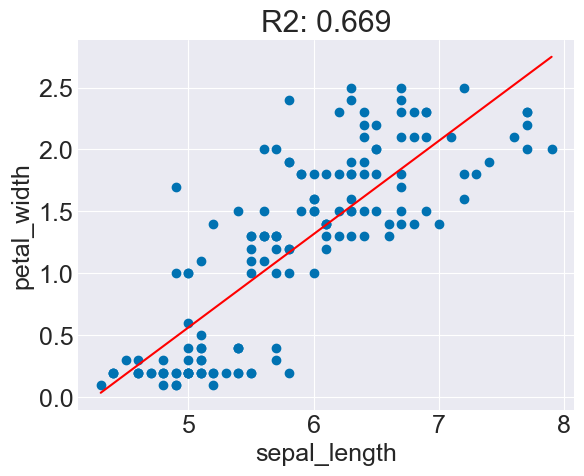

In [4]:
lin_reg_qr.linear_regression(['sepal_length'], 'petal_width', 'qr')
lin_reg_qr.scatter('sepal_length', 'petal_width', 'qr')
lin_reg_qr.show()

## Task 6: Benchmarking the least squares solvers on the wave dataset

You have added support for 3 least squares solver methods in `LinearRegression` — SciPy, Normal Equations, QR. Let's compare their stability on the wave dataset!

In the cell below, copy-and-paste your code that loads in the `wave_fit.csv`.

In [5]:
# YOUR CODE HERE

# retrieving wave_data (x, y) frmo CSV
data_wave = data.Data("data/wave.csv")

lin_reg_scipy = linear_regression.LinearRegression(data_wave)
lin_reg_normal = linear_regression.LinearRegression(data_wave)
lin_reg_qr = linear_regression.LinearRegression(data_wave)

### 6a. Varying the model polynomial degree

In the cell below, create a single plot with 3 curves — the $R^2$ obtained on the wave dataset fit set when separate polynomial regressions are fit to the wave fit set with polynomial degrees `1`, `2`, `3`, `...` with each of the 3 least square solver methods.

- The x axis should show the model polynomial degree.
- The y axis should show the fit set $R^2$.
- Limit the y axis range of the plotted $R^2$ values to span the valid range of values (*you should to set this explicitly and not assume your computed $R^2$ values will always be in the valid range*).
- The legend should indicate which solver corresponds to which colored curve.

Create 3 separate versions of the plot below (*have the below cell show all 3*):
1. the polynomial degree goes to 20.
2. the polynomial degree goes to 25.
3. the polynomial degree goes to 100.

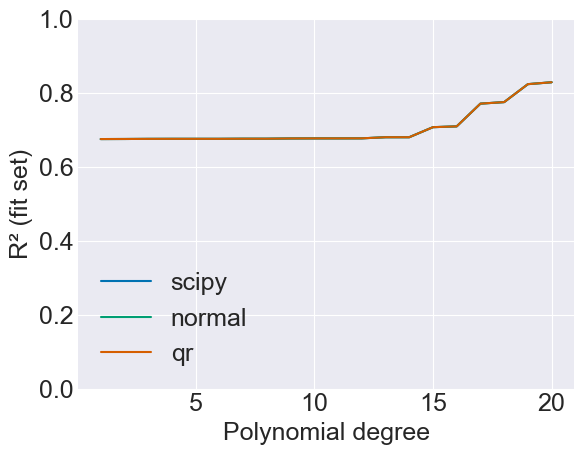

In [6]:
# up to 20
r2_scipy = []
r2_normal = []
r2_qr = []
degrees = []

for i in range(20):
    degree = i + 1
    degrees.append(degree)
    lin_reg_scipy.poly_regression("x", "y", degree, method="scipy")
    r2_scipy.append(lin_reg_scipy.R2)
    lin_reg_normal.poly_regression("x", "y", degree, method="normal")
    r2_normal.append(lin_reg_normal.R2)
    lin_reg_qr.poly_regression("x", "y", degree, method="qr")
    r2_qr.append(lin_reg_qr.R2)
    
plt.figure()

plt.plot(degrees, r2_scipy, label="scipy")
plt.plot(degrees, r2_normal, label="normal")
plt.plot(degrees, r2_qr, label="qr")

plt.xlabel('Polynomial degree')
plt.ylabel('R² (fit set)')
plt.ylim(bottom=0,top=1)
plt.legend()
    
plt.show()

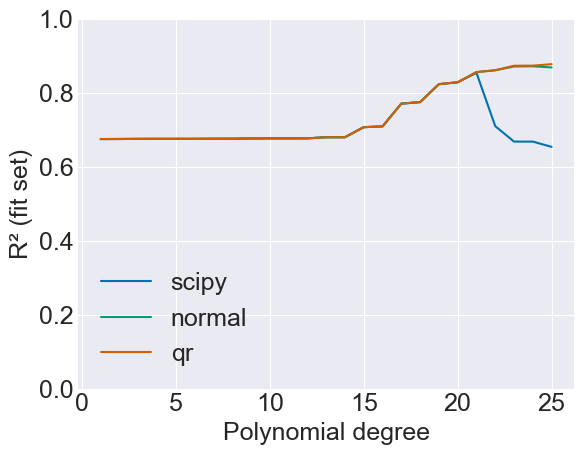

In [18]:
# up to 25
r2_scipy = []
r2_normal = []
r2_qr = []
degrees = []

for i in range(25):
    degree = i + 1
    degrees.append(degree)
    lin_reg_scipy.poly_regression("x", "y", degree, method="scipy")
    r2_scipy.append(lin_reg_scipy.R2)
    lin_reg_normal.poly_regression("x", "y", degree, method="normal")
    r2_normal.append(lin_reg_normal.R2)
    lin_reg_qr.poly_regression("x", "y", degree, method="qr")
    r2_qr.append(lin_reg_qr.R2)
    
plt.figure()

plt.plot(degrees, r2_scipy, label="scipy")
plt.plot(degrees, r2_normal, label="normal")
plt.plot(degrees, r2_qr, label="qr")

plt.xlabel('Polynomial degree')
plt.ylabel('R² (fit set)')
plt.ylim(bottom=0,top=1)
plt.legend()
    
plt.show()

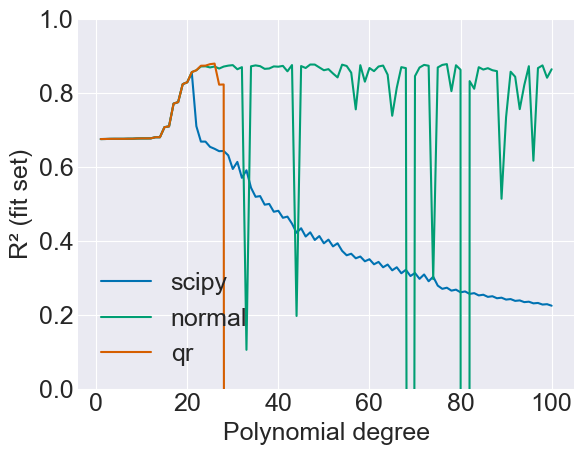

In [8]:
# up to 100
r2_scipy = []
r2_normal = []
r2_qr = []
degrees = []

for i in range(100):
    degree = i + 1
    degrees.append(degree)
    lin_reg_scipy.poly_regression("x", "y", degree, method="scipy")
    r2_scipy.append(lin_reg_scipy.R2)
    lin_reg_normal.poly_regression("x", "y", degree, method="normal")
    r2_normal.append(lin_reg_normal.R2)
    lin_reg_qr.poly_regression("x", "y", degree, method="qr")
    r2_qr.append(lin_reg_qr.R2)
    
plt.figure()

plt.plot(degrees, r2_scipy, label="scipy")
plt.plot(degrees, r2_normal, label="normal")
plt.plot(degrees, r2_qr, label="qr")

plt.xlabel('Polynomial degree')
plt.ylabel('R² (fit set)')
plt.ylim(bottom=0,top=1)
plt.legend()
    
plt.show()

### 6b. Visualizing differences among solvers when fitting high degree polynomials

Create 3 plots that show the model fit/predictions on the fit set when the polynomial degree is 3 larger than the point at which the solvers start to show departures in their $R^2$ values.

*It should be helpful/quick to copy-paste and modify your plotting code from the polynomial regression notebook.*

<Figure size 640x480 with 0 Axes>

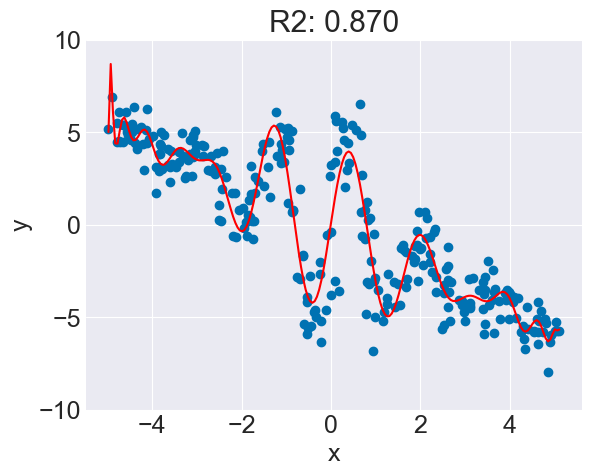

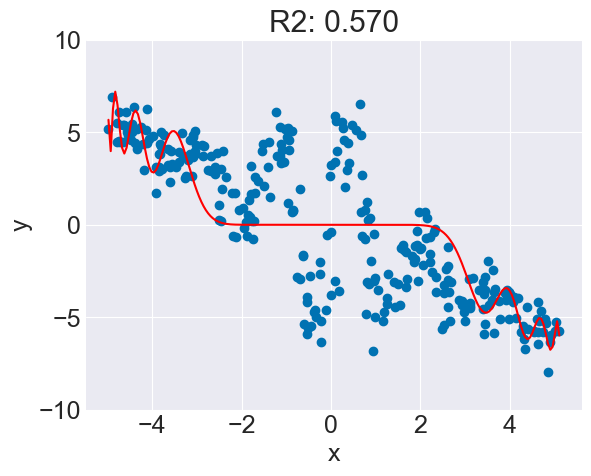

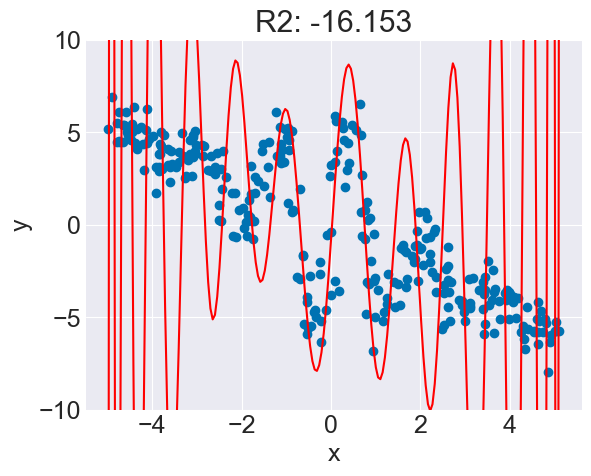

<Figure size 640x480 with 0 Axes>

In [ ]:
# YOUR CODE HERE

# plotting with NORMAL method on degree 32
lin_reg_fit = linear_regression.LinearRegression(data_wave)
lin_reg_fit.poly_regression('x', 'y', 32, method="normal")
plt.ylim(bottom=-10,top=10)
lin_reg_fit.scatter('x', 'y', "smh")
plt.figure()

# plott with SCIPY method on degree 24
lin_reg_fit = linear_regression.LinearRegression(data_wave)
lin_reg_fit.poly_regression('x', 'y', 24, method="scipy")
plt.ylim(bottom=-10,top=10)
lin_reg_fit.scatter('x', 'y', "smh")
plt.figure()

# plot with QR method on degree 30
lin_reg_fit = linear_regression.LinearRegression(data_wave)
lin_reg_fit.poly_regression('x', 'y', 30, method="qr")
plt.ylim(bottom=-10,top=10)
lin_reg_fit.scatter('x', 'y', "smh")
plt.figure()


### 6c. Questions

**Question 8:** Which solver most closely exhibits results that match our expectations for high $p$ values. 

**Question 9:** Based on your analysis above, what is your overall ranking of the best solvers, from most to least stable? Provide specific evidence from your results to support your ordering.

**Question 10:** Based on your plots in the previous subtask (with fixed $p$, one plot per solver), which among the that did not perform the best demonstrated the most resilience/graceful failure under the challenging computational conditions?

**Question 11:** What surprised you about the results that you obtained?

**Answer 8:** 

YOUR ANSWER HERE

Hypothetically, higher p values means we are moving towards a point where the regression line is trying to fit to the data itself so a consistent decrease in overall R2 would match our expectations. From plotting up to degree 100 for p values, scipy matches closest to our expectations as it's most stable.


**Answer 9:**

YOUR ANSWER HERE

1) scipy is most stable with a consistent downward trend in R2 values as p increases

2) normal is less stable as we have random spikes in R2 downwards as p increases 

3) QR is least stable as it drops down closer to infinity after degree 30.

**Answer 10:** 

YOUR ANSWER HERE

QR failed hard here. While scipy was pretty stable and normal occasionally failing at higher p values, QR just never recovered

**Answer 11:** 

YOUR ANSWER HERE

I guess I expected Gram-Schmidt and the QR decomp to be most stable but turns out it's the least stable LOL

## Task 7: Compare performance of the linear regression methods on brain data

The brain dataset contains electrical [EEG](https://en.wikipedia.org/wiki/Electroencephalography) measurements from different locations on the scalp of the human head.

### 7a. Run linear regressions on brain data with different solvers

1. In the cell below, load in the brain network `brain.csv` dataset.
2. Create `Data` and `LinearRegression` objects.
3. Load in the list of variable names in the brain dataset (62)
4. Do multiple linear regressions, separately for each of the 3 linear regression methods that you have implemented: Set all brain data variables except for the last one as the independent variables, the last variable is the dependent variable.
5. Compute and print the mean squared error (MSE) in the predictions made by each linear regression model and the actual y values.

In [28]:
# YOUR CODE HERE

# 1) + 2) load in Data and LinearRegression objects
brain_data = data.Data("data/brain.csv")
brain_lin_reg_normal = linear_regression.LinearRegression(brain_data)
brain_lin_reg_scipy = linear_regression.LinearRegression(brain_data)
brain_lin_reg_qr = linear_regression.LinearRegression(brain_data)

# 3) get all the variable names in brain dataset (headers)
brain_data_headers = brain_data.get_headers()

# 4) set ind and dep vars
ind_vars = brain_data_headers[:-1]
dep_vars = brain_data_headers[-1]

# 5 MSE!
brain_lin_reg_normal.linear_regression(ind_vars, dep_vars, method="normal")
brain_lin_reg_scipy.linear_regression(ind_vars, dep_vars, method="scipy")
brain_lin_reg_qr.linear_regression(ind_vars, dep_vars, method="qr")

print(f"MSE of normal method: {brain_lin_reg_normal.mse} ")
print(f"MSE of scipy method: {brain_lin_reg_scipy.mse}")
print(f"MSE of qr method: {brain_lin_reg_qr.mse}")

MSE of normal method: 1.5204354365493078e-23 
MSE of scipy method: 9.161492986507806e-26
MSE of qr method: 1.9090342201268253e-25


### 7b. Questions

**Question 12:** What are the mean squared errors for each of the regression methods on the brain data? Which method(s) do best and which do the worst **and why**?

**Answer 12:**

YOUR ANSWER HERE

MSE of normal method: 1.5204354365493078e-23 
MSE of scipy method: 9.161492986507806e-26
MSE of qr method: 1.9090342201268253e-25

This shows that our MSE is extremely low for each of the methods. SciPy does better by a factor of 10 and normal method does worse by a factor of 100 relative to the QR method.

As we mentioned in class, there is numerical isntability with the normal equation of solving for our coefficients. The uppertriangular transpose technique introduced by QR solves that instability. While SciPy is way more optimized as an official package for computation.